In [3]:
import pandas as pd
import os
import re
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.metrics import r2_score
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import MinMaxScaler

In [2]:
#data = pd.read_csv('/Users/natalialogvinova/Desktop/DS diploma/df_one_hot_encoded_171025.csv', sep = ',')

ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [ ]:
#columns_to_drop = ['№', 'id', 'title', 'description', 'key_skills', 'location', 'date_of_post', 'type', 'salary_to', 'currency', 'description_clean', 'salary_from_company_coefficient','salary_to_company_coefficient', 'salary_from_title_coefficient', 'salary_to_title_coefficient', 'salary_from_filled',]
#data_clean = data.drop(columns=columns_to_drop)

In [ ]:
#def show_missing_percentage(df):
    """
    Выводит процент пропущенных значений для каждого столбца
    """
    total_rows = len(df)
    missing_percent = (df.isnull().sum() / total_rows) * 100
    
    print("Процент пропущенных значений по столбцам:")
    print("-" * 50)
    for col, percent in missing_percent.items():
        print(f"{col}: {percent:.2f}%")
    
    return missing_percent

# Использование
missing_percent = show_missing_percentage(data_clean)

In [13]:
def fill_with_mode_simple(df, column_name):
    """
    Заполняет пропуски в столбце самым частотным значением
    """
    df_copy = df.copy()
    
    # Находим самое частотное значение (игнорируя NaN)
    mode_value = df_copy[column_name].mode()
    
    if not mode_value.empty:
        most_frequent = mode_value.iloc[0]
        print(f"Самое частотное значение в '{column_name}': {most_frequent}")
        
        # Заполняем пропуски
        df_copy[column_name] = df_copy[column_name].fillna(most_frequent)
    else:
        print(f"Не удалось найти самое частотное значение в '{column_name}'")
    
    return df_copy

In [9]:
#data_clean_filled = fill_with_mode_simple(data_clean, 'experience_from')

Самое частотное значение в 'experience_from': 1.0


In [10]:
#data_clean_filled = fill_with_mode_simple(data_clean_filled, 'experience_to')

Самое частотное значение в 'experience_to': 3.0


In [11]:
#data_clean_filled.to_csv('data_clean_one_hot_encoddecd_filled.csv')

Нормализуем данные.

In [4]:
data_clean_filled = pd.read_csv('/Users/natalialogvinova/Desktop/DS diploma/data_clean_one_hot_encoddecd_filled.csv', sep = ',')

## Линейная регрессия

In [5]:
X = data_clean_filled.loc[data_clean_filled["salary_from"].notnull(), :].drop(
    "salary_from", axis=1
)
y = data_clean_filled["salary_from"][X.index]

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

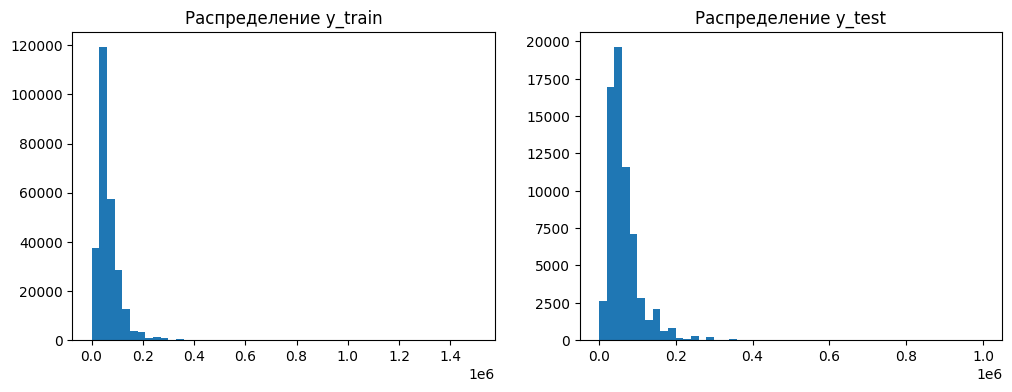

y_train stats: min=1.00, max=1500000.00, std=46836.77
y_test stats: min=2.00, max=1000000.00, std=47093.28


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Проверка выбросов в целевой переменной
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(y_train, bins=50)
plt.title('Распределение y_train')

plt.subplot(1, 2, 2)
plt.hist(y_test, bins=50) 
plt.title('Распределение y_test')

plt.show()

# Количественная проверка
print(f"y_train stats: min={y_train.min():.2f}, max={y_train.max():.2f}, std={y_train.std():.2f}")
print(f"y_test stats: min={y_test.min():.2f}, max={y_test.max():.2f}, std={y_test.std():.2f}")

In [10]:
from sklearn.preprocessing import MinMaxScaler

normalizer = MinMaxScaler()
X_train_normalized = normalizer.fit_transform(X_train)
X_test_normalized = normalizer.transform(X_test)   

X_train_normalized = pd.DataFrame(X_train_normalized, columns=normalizer.get_feature_names_out())
X_test_normalized = pd.DataFrame(X_test_normalized, columns=normalizer.get_feature_names_out())

In [11]:
def check_data_issues(X_train, X_test, y_train, y_test):
    print("=== ДИАГНОСТИКА ДАННЫХ ===")
    
    # 1. Размеры
    print(f"Размеры: X_train {X_train_normalized.shape}, X_test {X_test.shape}")
    
    # 2. Пропуски
    print(f"Пропуски в train: {X_train.isnull().sum().sum()}")
    print(f"Пропуски в test: {X_test.isnull().sum().sum()}")
    
    # 3. Статистики
    print("\nСтатистики по первому признаку:")
    print(f"Train - mean: {X_train.iloc[:, 0].mean():.2f}, std: {X_train.iloc[:, 0].std():.2f}")
    print(f"Test  - mean: {X_test.iloc[:, 0].mean():.2f}, std: {X_test.iloc[:, 0].std():.2f}")
    
    # 4. Масштабы признаков
    print("\nМасштабы признаков (min/max):")
    for i in range(min(3, X_train.shape[1])):
        train_range = X_train.iloc[:, i].max() - X_train.iloc[:, i].min()
        test_range = X_test.iloc[:, i].max() - X_test.iloc[:, i].min()
        print(f"Признак {i}: train {train_range:.2f}, test {test_range:.2f}")

check_data_issues(X_train_normalized, X_test_normalized, y_train, y_test)

=== ДИАГНОСТИКА ДАННЫХ ===
Размеры: X_train (265643, 236), X_test (66411, 236)
Пропуски в train: 0
Пропуски в test: 0

Статистики по первому признаку:
Train - mean: 0.50, std: 0.29
Test  - mean: 0.50, std: 0.29

Масштабы признаков (min/max):
Признак 0: train 1.00, test 1.00
Признак 1: train 1.00, test 1.00
Признак 2: train 1.00, test 1.00


In [12]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Создаем модели
lr = LinearRegression()
ridge = Ridge(alpha=1.0)    # параметр регуляризации
lasso = Lasso(alpha=0.1)    # параметр регуляризации

# Обучаем и оцениваем все модели
models = {
    'Linear Regression': lr,
    'Ridge': ridge, 
    'Lasso': lasso 
}

for name, model in models.items():
    print(f"\n=== {name} ===")
    
    # Обучение
    model.fit(X_train_normalized, y_train)
    
    # Предсказания
    pred_train = model.predict(X_train_normalized)
    pred_test = model.predict(X_test_normalized)
    
    # Оценка
    print(f"Train RMSE: {mean_squared_error(y_train, pred_train)**0.5:.2f}")
    print(f"Test RMSE: {mean_squared_error(y_test, pred_test)**0.5:.2f}")
    print(f"Train R²: {r2_score(y_train, pred_train):.4f}")
    print(f"Test R²: {r2_score(y_test, pred_test):.4f}")


=== Linear Regression ===
Train RMSE: 36752.64
Test RMSE: 132881845603.59
Train R²: 0.3842
Test R²: -7961959964050.8965

=== Ridge ===


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:193: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Train RMSE: 36824.86
Test RMSE: 37387.19
Train R²: 0.3818
Test R²: 0.3697

=== Lasso ===


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.877e+13, tolerance: 5.827e+10
  model = cd_fast.enet_coordinate_descent(


Train RMSE: 36754.82
Test RMSE: 37360.45
Train R²: 0.3842
Test R²: 0.3706


## Добавим PCA

In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50)  # оставляем 50 главных компонент
X_train_pca = pca.fit_transform(X_train_normalized)
X_test_pca = pca.transform(X_test_normalized)

print(f"После PCA: {X_train_pca.shape}")

После PCA: (265643, 50)


In [19]:
# Создаем модели
lr_PCA= LinearRegression()
ridge_PCA = Ridge(alpha=1.0)    # параметр регуляризации
lasso_PCA = Lasso(alpha=0.1)    # параметр регуляризации

# Обучаем и оцениваем все модели
models = {
    'Linear Regression': lr_PCA,
    'Ridge': ridge_PCA, 
    'Lasso': lasso_PCA
}

for name, model in models.items():
    print(f"\n=== {name} ===")
    
    # Обучение
    model.fit(X_train_pca, y_train)
    
    # Предсказания
    pred_train = model.predict(X_train_pca)
    pred_test = model.predict(X_test_pca)
    
    # Оценка
    print(f"Train RMSE: {mean_squared_error(y_train, pred_train)**0.5:.2f}")
    print(f"Test RMSE: {mean_squared_error(y_test, pred_test)**0.5:.2f}")
    print(f"Train R²: {r2_score(y_train, pred_train):.4f}")
    print(f"Test R²: {r2_score(y_test, pred_test):.4f}")


=== Linear Regression ===
Train RMSE: 36753.89
Test RMSE: 8946881107571.37
Train R²: 0.3842
Test R²: -36093751082833216.0000

=== Ridge ===


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:193: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Train RMSE: 36825.59
Test RMSE: 37388.48
Train R²: 0.3818
Test R²: 0.3697

=== Lasso ===


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.866e+13, tolerance: 5.827e+10
  model = cd_fast.enet_coordinate_descent(


Train RMSE: 36755.55
Test RMSE: 37361.72
Train R²: 0.3842
Test R²: 0.3706


## Случайный лес с грид-серчем

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split, GridSearchCV
import numpy as np

# Определение гиперпараметров для поиска
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [15, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

# Создание модели
rf_model = RandomForestRegressor(random_state=42)

# Поиск по сетке
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Обучение с подбором гиперпараметров
print("Начинаем подбор гиперпараметров...")
grid_search.fit(X_train, y_train)

# Лучшие параметры
print(f"\nЛучшие параметры: {grid_search.best_params_}")
print(f"Лучший score: {-grid_search.best_score_:.4f}")

# Используем лучшую модель
best_rf_model = grid_search.best_estimator_

# Предсказания
y_pred_train_rf = best_rf_model.predict(X_train)
y_pred_test_rf = best_rf_model.predict(X_test)

# Оценка качества
def evaluate_model(y_true, y_pred, dataset_name):
    print(f"\n=== {dataset_name} ===")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.2f}")
    print(f"MAE: {mean_absolute_error(y_true, y_pred):.2f}")
    print(f"R²: {r2_score(y_true, y_pred):.4f}")

evaluate_model(y_train, y_pred_train_rf, "TRAIN")
evaluate_model(y_test, y_pred_test_rf, "TEST")

## LightGBM

from xgboost import XGBRegressor

# Создаем и обучаем модель
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)


model.fit(X_train_normalized, y_train)

# Оценка
train_score = model.score(X_train_normalized, y_train)
test_score = model.score(X_test_normalized, y_test)
print(f"Train R²: {train_score:.4f}")
print(f"Test R²: {test_score:.4f}")

## BOW

In [6]:
data = pd.read_csv('/Users/natalialogvinova/Desktop/DS diploma/df_one_hot_encoded_171025.csv', sep = ',')

In [7]:
columns_to_drop = ['Unnamed: 0', '№', 'id', 'title',  'key_skills', 'location', 'date_of_post', 'type', 'salary_to', 'currency', 'description_clean', 'salary_from_company_coefficient','salary_to_company_coefficient', 'salary_from_title_coefficient', 'salary_to_title_coefficient', 'salary_from_filled',]
data.drop(columns=columns_to_drop, inplace=True)

In [8]:
data

,description,salary_from,experience_from,experience_to,no_experience,city_воронеж,city_деревня,city_екатеринбур,city_ижевск,city_казань,...,title_key_электромонтер,title_key_электросварщик,title_key_энергетик,title_key_юрисконсульт,title_key_юрист,month_4,month_5,month_6,month_8,month_9
0,"вакансия компании: ооо пк предприятие ""пик"" ...",160000.0,6.0,NaN,False,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,"торгово-производственная компания зао ""росма...",62000.0,1.0,3.0,False,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,в гк миланстрой требуется начальник участка!...,130000.0,1.0,3.0,False,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,гк «олимпроект» - лидирующая компания в сф...,80000.0,1.0,3.0,False,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,компания «ортоника» является одним из веду...,250000.0,6.0,NaN,False,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
332049,{'requirement': 'подтвержденные навыки построе...,200000.0,3.0,6.0,False,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
332050,"{'requirement': 'опыт работы с spring boot, sp...",350000.0,1.0,NaN,False,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
332051,{'requirement': 'опыт работы на проектах по вн...,200000.0,3.0,6.0,False,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
332052,{'requirement': 'высшее профильное образование...,90000.0,1.0,NaN,False,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [14]:
data_clean_2_filled = fill_with_mode_simple(data, 'experience_from')

Самое частотное значение в 'experience_from': 1.0


In [15]:
data_clean_2_filled = fill_with_mode_simple(data_clean_2_filled, 'experience_to')

Самое частотное значение в 'experience_to': 3.0


In [16]:
X_2 = data_clean_2_filled.loc[data_clean_2_filled["salary_from"].notnull(), :].drop(
    "salary_from", axis=1
)
y_2 = data_clean_2_filled["salary_from"][X_2.index]

In [17]:
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.2, random_state=1)

In [22]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LinearRegression
from scipy.sparse import hstack

import nltk
nltk.download('stopwords') 
from nltk.corpus import stopwords
russian_stop_words = stopwords.words('russian')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/natalialogvinova/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [23]:
# Предположим, что X_train, X_test содержат разные признаки, включая текстовые
text_column = 'description'  # название текстовой колонки

# Создание BOW представления
vectorizer = CountVectorizer(max_features=1000, stop_words=russian_stop_words)
X_train_bow = vectorizer.fit_transform(X_train_2[text_column])
X_test_bow = vectorizer.transform(X_test_2[text_column])

# Удаляем текстовую колонку из исходных данных
X_train_other = X_train_2.drop(columns=[text_column])
X_test_other = X_test_2.drop(columns=[text_column])

# Объединяем BOW с другими признаками
numeric_cols = X_train_other.select_dtypes(include=['int64', 'float64']).columns
X_train_numeric = X_train_other[numeric_cols].values
X_test_numeric = X_test_other[numeric_cols].values

# Объединяем
X_train_combined = hstack([X_train_numeric, X_train_bow])
X_test_combined = hstack([X_test_numeric, X_test_bow])


In [24]:
X_train_combined_df = pd.DataFrame(X_train_combined.toarray())
X_test_combined_df = pd.DataFrame(X_test_combined.toarray())

In [25]:
from sklearn.preprocessing import MinMaxScaler

normalizer = MinMaxScaler()
X_train_normalized_2 = normalizer.fit_transform(X_train_combined_df)
X_test_normalized_2 = normalizer.transform(X_test_combined_df)   

X_train_normalized_2 = pd.DataFrame(X_train_normalized_2, columns=normalizer.get_feature_names_out())
X_test_normalized_2 = pd.DataFrame(X_test_normalized_2, columns=normalizer.get_feature_names_out())

In [27]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Создаем модели
lr_2 = LinearRegression()
ridge_2 = Ridge(alpha=1.0)    # параметр регуляризации
lasso_2 = Lasso(alpha=0.1)    # параметр регуляризации

# Обучаем и оцениваем все модели
models_2 = {
    'Linear Regression': lr_2,
    'Ridge': ridge_2
}

for name, model in models_2.items():
    print(f"\n=== {name} ===")
    
    # Обучение
    model.fit(X_train_normalized_2 , y_train_2)
    
    # Предсказания
    pred_train = model.predict(X_train_normalized_2)
    pred_test = model.predict(X_test_normalized_2)
    
    # Оценка
    print(f"Train RMSE: {mean_squared_error(y_train_2, pred_train)**0.5:.2f}")
    print(f"Test RMSE: {mean_squared_error(y_test_2, pred_test)**0.5:.2f}")
    print(f"Train R²: {r2_score(y_train_2, pred_train):.4f}")
    print(f"Test R²: {r2_score(y_test_2, pred_test):.4f}")


=== Linear Regression ===
Train RMSE: 33671.05
Test RMSE: 9842533092890.77
Train R²: 0.4832
Test R²: -43681993904886520.0000

=== Ridge ===


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:193: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Train RMSE: 33750.43
Test RMSE: 34288.62
Train R²: 0.4807
Test R²: 0.4699


## TF-IDF

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    max_features=1000,      # максимальное количество признаков
    min_df=2,              # игнорировать термины, встречающиеся реже чем в 2 документах
    max_df=0.8,            # игнорировать термины, встречающиеся чаще чем в 80% документов
    stop_words=russian_stop_words  
)


X_train_2_tfidf = tfidf.fit_transform(X_train_2['description'])
X_test_2_tfidf = tfidf.fit_transform(X_test_2['description'])

# Объединяем BOW с другими признаками
numeric_cols = X_train_other.select_dtypes(include=['int64', 'float64']).columns
X_train_numeric = X_train_other[numeric_cols].values
X_test_numeric = X_test_other[numeric_cols].values

# Объединяем
X_train_tfidf_combined = hstack([X_train_numeric, X_train_2_tfidf])
X_test_tfidf_combined = hstack([X_test_numeric, X_test_2_tfidf])

In [36]:
X_train_tfidf_combined_df = pd.DataFrame(X_train_tfidf_combined.toarray())
X_test_tfidf_combined_df = pd.DataFrame(X_test_tfidf_combined .toarray())

In [37]:
X_train_tfidf_combined_df

,0,1,2,3,4,5,6,7,8,9,...,1223,1224,1225,1226,1227,1228,1229,1230,1231,1232
0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.102415,0.000000,0.0,0.0,0.0,0.0
1,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
2,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
3,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
4,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.113137,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265638,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
265639,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
265640,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
265641,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0


In [38]:
from sklearn.preprocessing import MinMaxScaler

# Нормализация
normalizer = MinMaxScaler()
X_train_normalized_tfidf = normalizer.fit_transform(X_train_tfidf_combined_df)
X_test_normalized_tfidf = normalizer.transform(X_test_tfidf_combined_df)   

X_train_normalized_tfidf = pd.DataFrame(
    X_train_normalized_tfidf,  # нормализованный массив
    columns=X_train_tfidf_combined_df.columns  # названия колонок из исходного DataFrame
)
X_test_normalized_tfidf = pd.DataFrame(
    X_test_normalized_tfidf,   # нормализованный массив  
    columns=X_test_tfidf_combined_df.columns   # названия колонок
)

In [39]:
X_train_normalized_tfidf

,0,1,2,3,4,5,6,7,8,9,...,1223,1224,1225,1226,1227,1228,1229,1230,1231,1232
0,0.166667,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.129969,0.000000,0.0,0.0,0.0,0.0
1,0.166667,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
2,0.166667,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
3,0.166667,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
4,0.166667,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.210561,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265638,0.166667,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
265639,0.166667,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
265640,0.166667,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
265641,0.166667,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0


In [40]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Создаем модели
lr_3 = LinearRegression()
ridge_3 = Ridge(alpha=1.0)    # параметр регуляризации
lasso_3 = Lasso(alpha=0.1)    # параметр регуляризации

# Обучаем и оцениваем все модели
models_3 = {
    'Linear Regression': lr_3,
    'Ridge': ridge_3, 
}

for name, model in models_3.items():
    print(f"\n=== {name} ===")
    
    # Обучение
    model.fit(X_train_normalized_tfidf , y_train_2)
    
    # Предсказания
    pred_train = model.predict(X_train_normalized_tfidf)
    pred_test = model.predict(X_test_normalized_tfidf)
    
    # Оценка
    print(f"Train RMSE: {mean_squared_error(y_train_2, pred_train)**0.5:.2f}")
    print(f"Test RMSE: {mean_squared_error(y_test_2, pred_test)**0.5:.2f}")
    print(f"Train R²: {r2_score(y_train_2, pred_train):.4f}")
    print(f"Test R²: {r2_score(y_test_2, pred_test):.4f}")


=== Linear Regression ===
Train RMSE: 33702.26
Test RMSE: 7837010033209.09
Train R²: 0.4822
Test R²: -27694242590271684.0000

=== Ridge ===


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:193: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Train RMSE: 33779.75
Test RMSE: 38904.51
Train R²: 0.4798
Test R²: 0.3175
